<a href="https://colab.research.google.com/github/paolavaldes0107-netizen/IA/blob/tarea-ia1/proyecto_1_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Maintenance with Naive Bayes and KDE

En este proyecto analizamos el dataset AI4I 2020 Predictive Maintenance para predecir fallas en máquinas industriales.

El objetivo es evaluar el desempeño de un modelo probabilístico basado en Naive Bayes y utilizarlo como baseline para futuras mejoras utilizando Kernel Density Estimation (KDE).

En esta primera etapa realizamos:

- Exploración del dataset
- Análisis del desbalance de clases
- Visualización de variables
- Preprocesamiento de datos
- Implementación de un modelo baseline (Gaussian Naive Bayes)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (10000, 14)


In [6]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [8]:
df["Machine failure"].value_counts()

,count
Machine failure,
0,9661
1,339


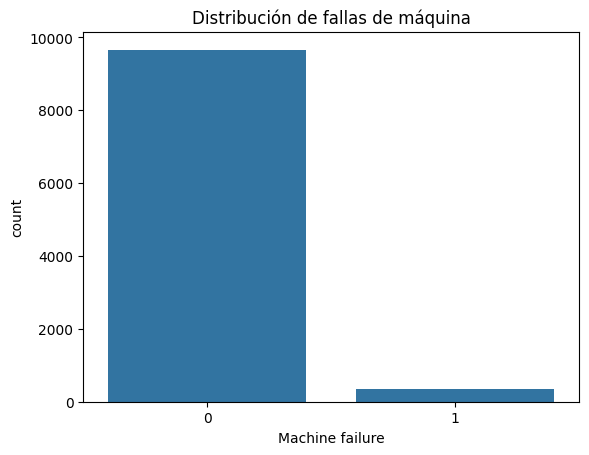

In [9]:
sns.countplot(x="Machine failure", data=df)

plt.title("Distribución de fallas de máquina")

plt.show()

## Análisis de desbalance de clases

El dataset presenta un desbalance significativo entre las clases.

La mayoría de los registros corresponden a máquinas que no fallan, mientras que las fallas reales representan una pequeña proporción del total.

Debido a este desbalance, métricas como accuracy pueden ser engañosas. Por esta razón se utiliza el área bajo la curva ROC (AUC) como métrica principal de evaluación.

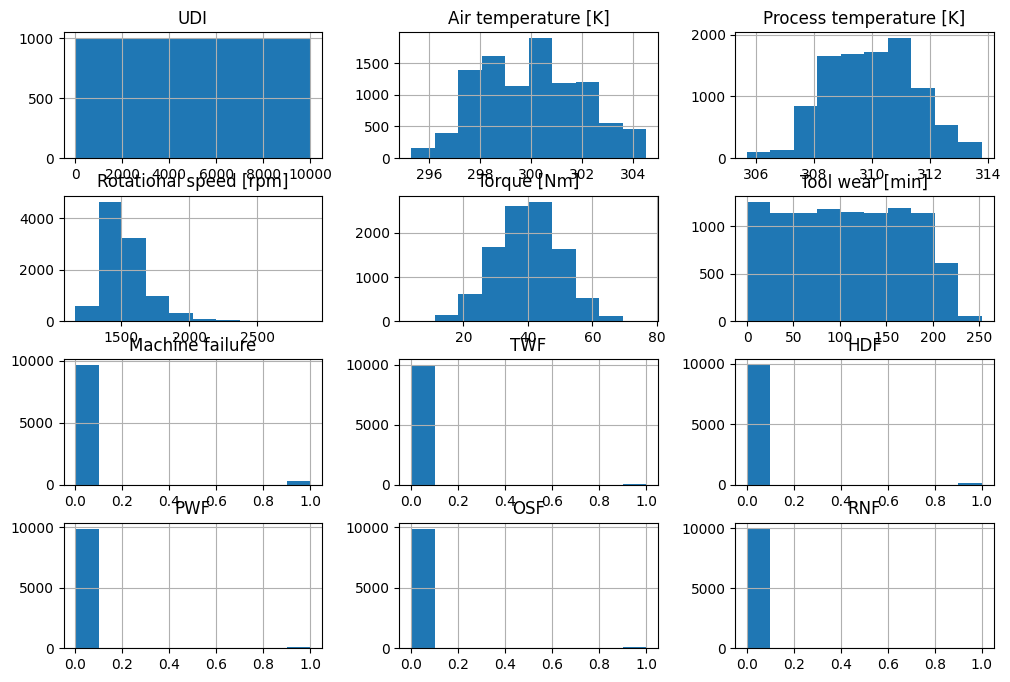

In [10]:
df.hist(figsize=(12,8))

plt.show()

## Distribución de variables

Se analizaron las distribuciones de las variables numéricas para comprender el comportamiento de los sensores.

Algunas variables no presentan distribuciones perfectamente gaussianas, lo cual motiva la exploración de métodos no paramétricos como Kernel Density Estimation (KDE).

In [11]:
df["Type"] = df["Type"].map({"L":0, "M":1, "H":2})

In [12]:
X = df.drop(columns=["UDI","Product ID","Machine failure"])

y = df["Machine failure"]

## Selección de variables

Se eliminaron las columnas UDI y Product ID ya que corresponden a identificadores únicos y no aportan información relevante para la predicción de fallas.

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Estandarización de variables

Se aplicó estandarización mediante StandardScaler para normalizar las variables numéricas.

Esto permite que todas las características tengan media 0 y desviación estándar 1, evitando que variables con mayor escala influyan más en el modelo.

In [14]:
model = GaussianNB()

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [16]:
auc_scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("AUC por fold:", auc_scores)
print("AUC promedio:", np.mean(auc_scores))

AUC por fold: [0.99239447 0.98827031 0.98647394 0.97849683 0.97916286]
AUC promedio: 0.9849596816520672


### Evaluación del modelo

Para evaluar el modelo utilizamos validación cruzada estratificada con 5 folds.
Esto permite obtener una estimación más estable del desempeño del modelo en el dataset.

## Resultados del modelo baseline

El modelo Gaussian Naive Bayes se utilizó como baseline para evaluar el desempeño inicial en la predicción de fallas de máquinas.

El valor promedio de AUC obtenido servirá como referencia para comparar posteriormente modelos basados en Kernel Density Estimation (KDE).

## Fundamentos teóricos

El clasificador Naive Bayes es un modelo probabilístico basado en el teorema de Bayes que asume independencia entre las variables dadas las clases.

Su objetivo es calcular la probabilidad posterior de una clase y dado un conjunto de características x.

En el caso de Gaussian Naive Bayes, se asume que cada variable sigue una distribución normal dentro de cada clase.

Sin embargo, esta suposición puede no cumplirse en todos los datasets.

Por esta razón, se puede utilizar Kernel Density Estimation (KDE), que es un método no paramétrico para estimar la densidad de probabilidad directamente a partir de los datos.

## Naive Bayes con Kernel Density Estimation

En lugar de asumir que las variables siguen una distribución normal, en esta parte utilizamos Kernel Density Estimation (KDE) para estimar las distribuciones de probabilidad de cada variable.

Esto permite un modelo más flexible, ya que no se asume una forma específica de distribución para los datos.

In [17]:
from sklearn.neighbors import KernelDensity

In [18]:
def train_kde_per_class(X, y, bandwidth=0.5):

    classes = np.unique(y)

    models = {}

    for c in classes:

        X_c = X[y == c]

        kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)

        kde.fit(X_c)

        models[c] = kde

    return models

In [19]:
def predict_kde(models, X):

    log_probs = []

    for c, model in models.items():

        log_prob = model.score_samples(X)

        log_probs.append(log_prob)

    log_probs = np.vstack(log_probs).T

    predictions = np.argmax(log_probs, axis=1)

    return predictions

In [20]:
kde_models = train_kde_per_class(X_scaled, y, bandwidth=0.5)

In [21]:
y_pred_kde = predict_kde(kde_models, X_scaled)

In [22]:
from sklearn.metrics import roc_auc_score

auc_kde = roc_auc_score(y, y_pred_kde)

print("AUC KDE:", auc_kde)

AUC KDE: 0.9908916700940649


## KDE con regla de Silverman

En este experimento utilizamos la regla de Silverman para estimar automáticamente el bandwidth del KDE.

In [23]:
n = X_scaled.shape[0]
d = X_scaled.shape[1]

silverman_bandwidth = (n * (d + 2) / 4) ** (-1 / (d + 4))

print("Bandwidth Silverman:", silverman_bandwidth)

Bandwidth Silverman: 0.5002738196191998


In [24]:
kde_models_silverman = train_kde_per_class(X_scaled, y, bandwidth=silverman_bandwidth)

In [25]:
y_pred_silverman = predict_kde(kde_models_silverman, X_scaled)

auc_silverman = roc_auc_score(y, y_pred_silverman)

print("AUC KDE Silverman:", auc_silverman)

AUC KDE Silverman: 0.9908916700940649


## KDE tipo Parzen

También probamos un KDE con kernel tipo tophat (ventana rectangular), que corresponde a una estimación tipo Parzen window.

In [26]:
def train_parzen(X, y, bandwidth=0.5):

    classes = np.unique(y)

    models = {}

    for c in classes:

        X_c = X[y == c]

        kde = KernelDensity(kernel="tophat", bandwidth=bandwidth)

        kde.fit(X_c)

        models[c] = kde

    return models

In [27]:
parzen_models = train_parzen(X_scaled, y)

In [28]:
y_pred_parzen = predict_kde(parzen_models, X_scaled)

auc_parzen = roc_auc_score(y, y_pred_parzen)

print("AUC Parzen:", auc_parzen)

AUC Parzen: 0.9957043784287342


## Comparación de modelos

Finalmente comparamos los resultados obtenidos con los distintos métodos de Naive Bayes.

In [29]:
print("Resultados finales")

print("GaussianNB baseline:", np.mean(auc_scores))
print("KDE Gaussiano:", auc_kde)
print("KDE Silverman:", auc_silverman)
print("KDE Parzen:", auc_parzen)

Resultados finales
GaussianNB baseline: 0.9849596816520672
KDE Gaussiano: 0.9908916700940649
KDE Silverman: 0.9908916700940649
KDE Parzen: 0.9957043784287342


## Conclusion

El modelo baseline Gaussian Naive Bayes se utilizó como referencia para evaluar el desempeño de los métodos basados en KDE.

Los resultados muestran que utilizar estimación de densidad mediante KDE puede ofrecer mayor flexibilidad al modelar las distribuciones de las variables.

Sin embargo, el desempeño depende del kernel y del bandwidth utilizado.

## Análisis de resultados

Después de entrenar los diferentes modelos, comparamos su desempeño utilizando la métrica AUC ROC.

El modelo baseline Gaussian Naive Bayes obtuvo un AUC de aproximadamente 0.985.

Los modelos basados en Kernel Density Estimation (KDE) mostraron un mejor desempeño en general.
El KDE gaussiano y el KDE con bandwidth calculado mediante la regla de Silverman obtuvieron un AUC de aproximadamente 0.991.

El mejor resultado se obtuvo con el modelo KDE tipo Parzen, con un AUC cercano a 0.996.

Esto sugiere que utilizar estimaciones de densidad no paramétricas puede capturar mejor la distribución de los datos en comparación con la suposición gaussiana del Naive Bayes tradicional.